<a href="https://colab.research.google.com/github/temesgenaddise/cosc-650-applied-llm-systems/blob/main/Week-2/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Inference and Sampling

This notebook runs distilgpt2 locally on CPU and obtains every reported number directly from the loaded model.

##Libraries

In [1]:
!pip install -q transformers torch numpy matplotlib pandas

import os, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
torch.manual_seed(0)
MODEL_NAME = 'distilgpt2'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
try:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, attn_implementation='eager'
    )
except TypeError:
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

model.to('cpu')
model.eval()
config = model.config
print(f'Device: {next(model.parameters()).device}')
print(f'{MODEL_NAME}: {config.n_layer} layers, {config.n_head} heads, embedding dimension {config.n_embd}, vocabulary size {config.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Device: cpu
distilgpt2: 6 layers, 12 heads, embedding dimension 768, vocabulary size 50257


##Part 1: Trace the forward pass

The prompt below is tokenized, embedded, and passed through the model. Attention is requested explicitly using the eager attention path. The selected attention row is for the last prompt token at layer 0, head 0, so all prompt positions are allowed by the causal mask.

In [2]:
prompt = 'Artificial intelligence can help people'
encoded = tokenizer(prompt, return_tensors='pt')
input_ids = encoded['input_ids']
ids = input_ids[0]

print('Prompt:', repr(prompt))
print('Token IDs:', ids.tolist())
for position, token_id in enumerate(ids.tolist()):
    token_text = tokenizer.decode([token_id])
    print(f'  position {position}: ID {token_id:5d} -> {token_text!r}')

with torch.no_grad():
    embeddings = model.transformer.wte(input_ids)
print('\nEmbedding tensor shape (batch, sequence, dimension):', tuple(embeddings.shape))
print('Embedding dimension reported by the model:', embeddings.shape[-1])

Prompt: 'Artificial intelligence can help people'
Token IDs: [8001, 9542, 4430, 460, 1037, 661]
  position 0: ID  8001 -> 'Art'
  position 1: ID  9542 -> 'ificial'
  position 2: ID  4430 -> ' intelligence'
  position 3: ID   460 -> ' can'
  position 4: ID  1037 -> ' help'
  position 5: ID   661 -> ' people'

Embedding tensor shape (batch, sequence, dimension): (1, 6, 768)
Embedding dimension reported by the model: 768


In [3]:
with torch.no_grad():
    outputs = model(**encoded, output_attentions=True, use_cache=False)

if outputs.attentions is None:
    raise RuntimeError('No attention weights were returned. Reload the model with attn_implementation="eager".')

layer_index = 0
head_index = 0
query_position = ids.shape[0] - 1
attention_row = outputs.attentions[layer_index][0, head_index, query_position, :]

print(f'Attention: layer {layer_index}, head {head_index}, query position {query_position}')
print(f'Sum over allowed positions: {attention_row.sum().item():.8f}')
for position, (token_id, weight) in enumerate(zip(ids.tolist(), attention_row.tolist())):
    print(f'  key position {position}: {tokenizer.decode([token_id])!r:18s} weight={weight:.8f}')

logits = outputs.logits
next_token_logits = logits[0, -1, :]
next_token_probabilities = torch.softmax(next_token_logits, dim=-1)
top_probabilities, top_ids = torch.topk(next_token_probabilities, k=10)

print('\nLogits shape (batch, sequence, vocabulary):', tuple(logits.shape))
print('Vocabulary dimension from logits:', logits.shape[-1])
print('Top 10 next-token probabilities:')
top_rows = []
for rank, (probability, token_id) in enumerate(zip(top_probabilities.tolist(), top_ids.tolist()), 1):
    top_rows.append({'rank': rank, 'token_id': token_id,
                     'token': tokenizer.decode([token_id]), 'probability': probability})
display(pd.DataFrame(top_rows).style.format({'probability': '{:.8f}'}))

Attention: layer 0, head 0, query position 5
Sum over allowed positions: 1.00000000
  key position 0: 'Art'              weight=0.27888545
  key position 1: 'ificial'          weight=0.24042380
  key position 2: ' intelligence'    weight=0.19166027
  key position 3: ' can'             weight=0.05668365
  key position 4: ' help'            weight=0.15754880
  key position 5: ' people'          weight=0.07479798

Logits shape (batch, sequence, vocabulary): (1, 6, 50257)
Vocabulary dimension from logits: 50257
Top 10 next-token probabilities:


,rank,token_id,token,probability
0,1,284,to,0.13983393
1,2,351,with,0.09776590
2,3,1365,better,0.04492951
3,4,1833,understand,0.04016868
4,5,287,in,0.02909223
5,6,787,make,0.02448597
6,7,8494,solve,0.02345576
7,8,1064,find,0.02202809
8,9,2193,learn,0.02082875
9,10,19271,cope,0.02079778


##Part 2: Build the sampling explorer

The functions below operate on the model's real next-token logits. Temperature is applied to logits. Top-k and top-p mask tokens and then renormalize the surviving probabilities. Five comparisons are shown: temperature, top-k, top-p, temperature + top-k, and temperature + top-p.

In [4]:
real_logits = next_token_logits.detach().cpu().numpy().astype(np.float64)

def stable_softmax(values):
    shifted = values - np.max(values)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum()

def apply_temperature(logit_values, temperature):
    if temperature <= 0:
        raise ValueError('Temperature must be greater than zero.')
    return stable_softmax(logit_values / temperature)

def apply_top_k(probabilities, k):
    if not 1 <= k <= probabilities.size:
        raise ValueError('k must be between 1 and the vocabulary size.')
    kept_indices = np.argpartition(probabilities, -k)[-k:]
    filtered = np.zeros_like(probabilities)
    filtered[kept_indices] = probabilities[kept_indices]
    return filtered / filtered.sum()

def apply_top_p(probabilities, threshold):
    if not 0 < threshold <= 1:
        raise ValueError('top-p must be in the interval (0, 1].')
    order = np.argsort(probabilities)[::-1]
    cumulative = np.cumsum(probabilities[order])
    cutoff = np.searchsorted(cumulative, threshold, side='left') + 1
    filtered = np.zeros_like(probabilities)
    filtered[order[:cutoff]] = probabilities[order[:cutoff]]
    return filtered / filtered.sum()

def run_sampling_pipeline(logit_values, temperature=1.0, top_k=None, top_p=None):
    probabilities = apply_temperature(logit_values, temperature)
    if top_k is not None:
        probabilities = apply_top_k(probabilities, top_k)
    if top_p is not None:
        probabilities = apply_top_p(probabilities, top_p)
    return probabilities

base_distribution = run_sampling_pipeline(real_logits)
assert np.isclose(base_distribution.sum(), 1.0)

/tmp/ipykernel_19178/3116061161.py:24: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


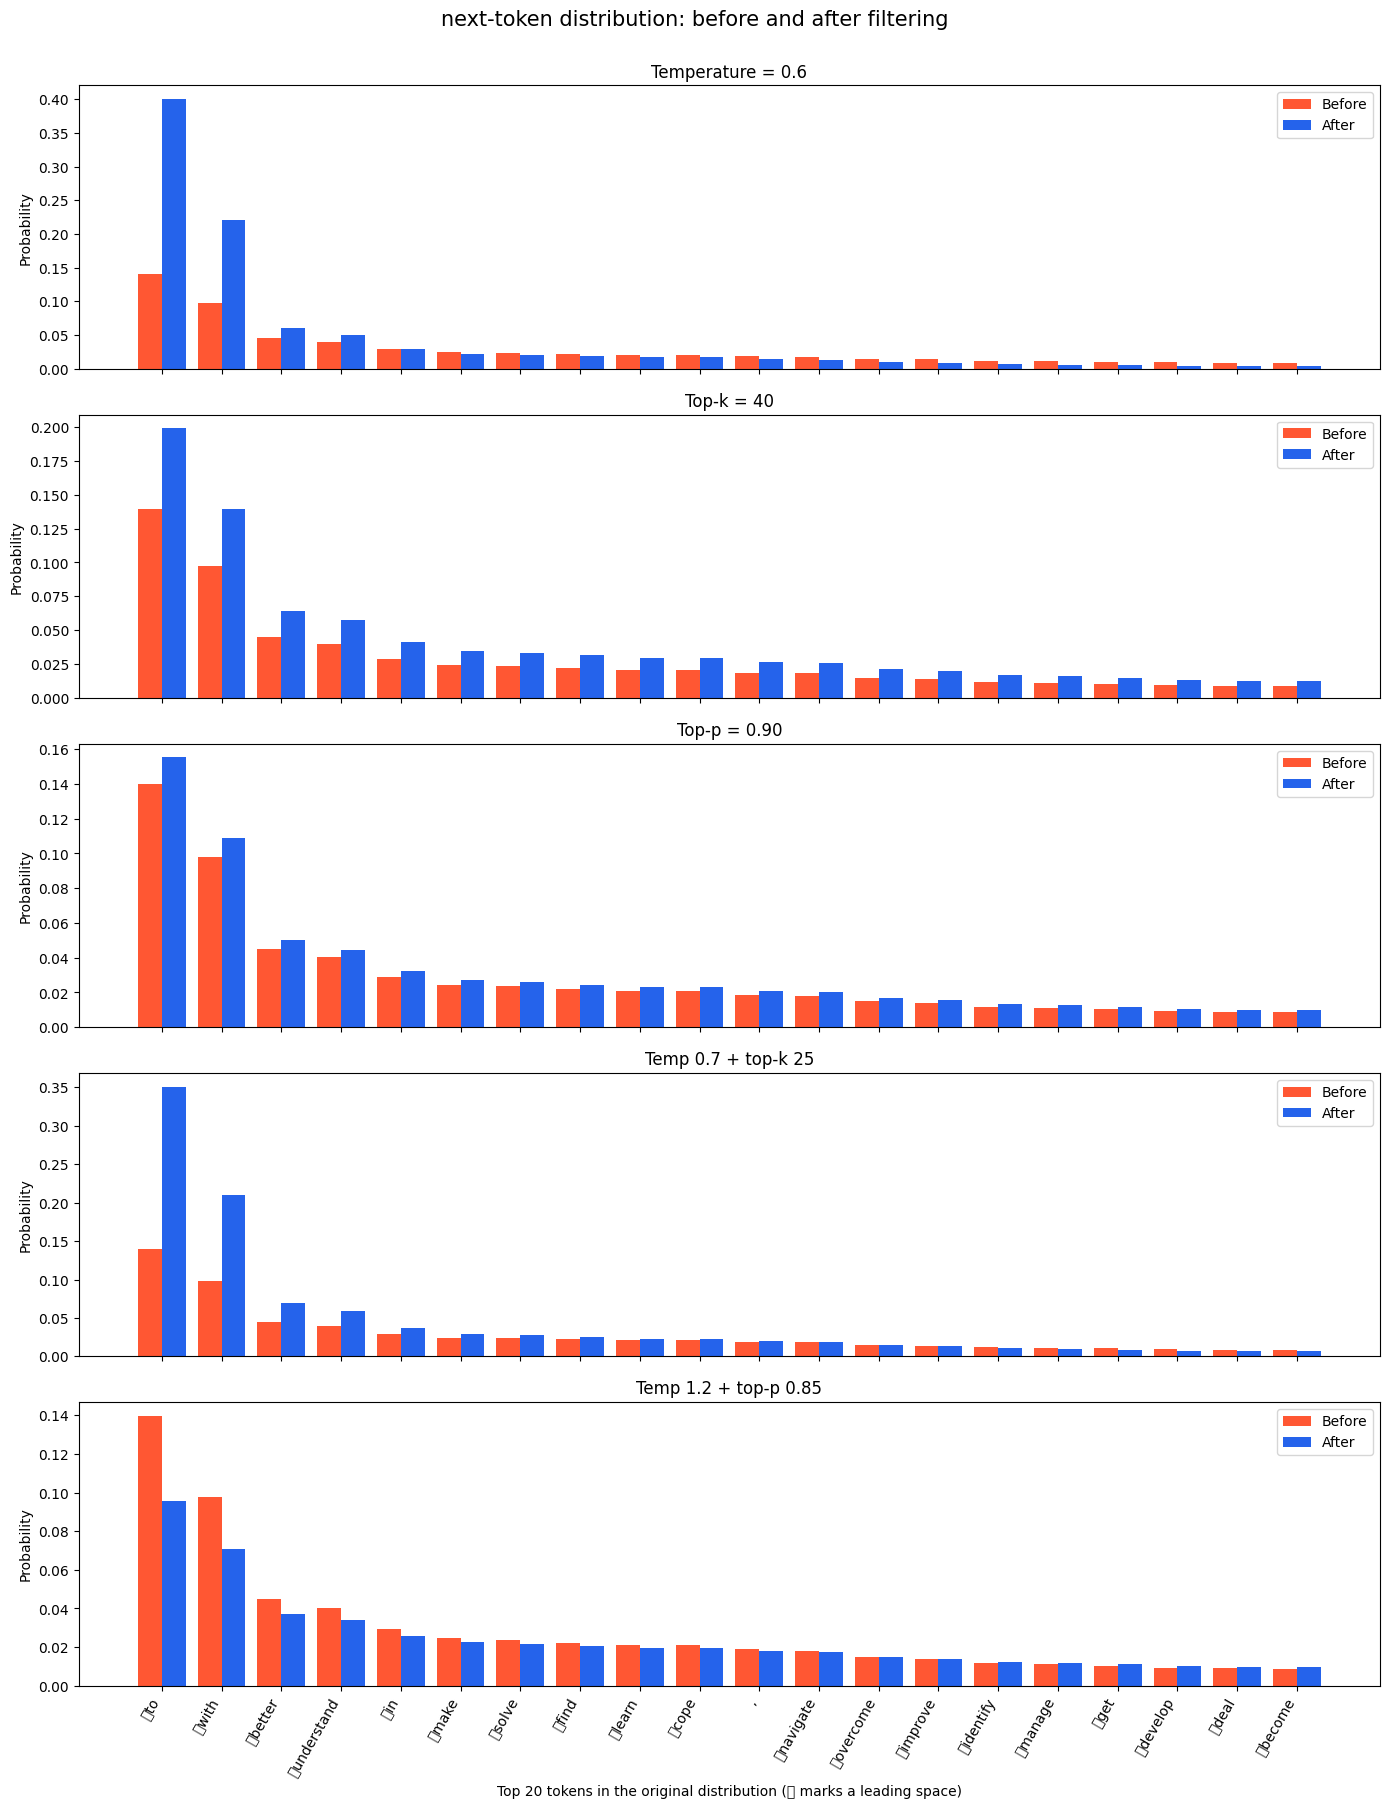

In [5]:
comparisons = [
    ('Temperature = 0.6', run_sampling_pipeline(real_logits, temperature=0.6)),
    ('Top-k = 40', run_sampling_pipeline(real_logits, top_k=40)),
    ('Top-p = 0.90', run_sampling_pipeline(real_logits, top_p=0.90)),
    ('Temp 0.7 + top-k 25', run_sampling_pipeline(real_logits, temperature=0.7, top_k=25)),
    ('Temp 1.2 + top-p 0.85', run_sampling_pipeline(real_logits, temperature=1.2, top_p=0.85)),
]

reference_indices = np.argsort(base_distribution)[::-1][:20]
reference_labels = [tokenizer.decode([int(i)]).replace(' ', '␠') for i in reference_indices]
x = np.arange(len(reference_indices))

fig, axes = plt.subplots(len(comparisons), 1, figsize=(14, 18), sharex=True)
for axis, (label, changed_distribution) in zip(axes, comparisons):
    axis.bar(x - 0.2, base_distribution[reference_indices], width=0.4, label='Before', color='#FF5733')
    axis.bar(x + 0.2, changed_distribution[reference_indices], width=0.4, label='After', color='#2563eb')
    axis.set_title(label)
    axis.set_ylabel('Probability')
    axis.legend()
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(reference_labels, rotation=60, ha='right')
axes[-1].set_xlabel('Top 20 tokens in the original distribution (␠ marks a leading space)')
fig.suptitle('next-token distribution: before and after filtering', y=1.002, fontsize=15)
plt.tight_layout()
plt.show()

##Part 3: Evaluate three settings with real figures

Chosen three settings

1. Temperature 0.7
2. top-k 40
3. temperature 1.2, top-k 100, and top-p 0.9

Predictions:

Temperature 0.7: I expect a sharper distribution, lower entropy, and a larger maximum probability. Because there is no cutoff, all tokens with numerically positive probability should survive.

Top-k 40: I expect exactly 40 tokens to survive. Renormalization should increase the maximum probability and reduce entropy.

Temperature 1.2 + top-k 100 + top-p 0.90: I expect temperature to flatten the distribution first. Top-k limits the candidates to at most 100, and top-p may reduce that number further. The result should be more selective than temperature alone.

In [6]:
def distribution_metrics(probabilities):
    positive = probabilities[probabilities > 0]
    return {
        'entropy_nats': float(-np.sum(positive * np.log(positive))),
        'maximum_probability': float(np.max(probabilities)),
        'tokens_surviving': int(np.count_nonzero(probabilities)),
    }

settings = [
    ('Temperature 0.7', {'temperature': 0.7}),
    ('Top-k 40', {'temperature': 1.0, 'top_k': 40}),
    ('Temp 1.2 + top-k 100 + top-p 0.90',
     {'temperature': 1.2, 'top_k': 100, 'top_p': 0.90}),
]

baseline_metrics = distribution_metrics(base_distribution)
rows = [{'setting': 'Baseline', **baseline_metrics}]
evaluated_distributions = {}
for setting_name, parameters in settings:
    distribution = run_sampling_pipeline(real_logits, **parameters)
    evaluated_distributions[setting_name] = distribution
    rows.append({'setting': setting_name, **distribution_metrics(distribution)})

metrics_table = pd.DataFrame(rows)
display(metrics_table.style.format({
    'entropy_nats': '{:.6f}',
    'maximum_probability': '{:.8f}',
}))

,setting,entropy_nats,maximum_probability,tokens_surviving
0,Baseline,4.697372,0.13983178,50257
1,Temperature 0.7,2.956645,0.31225113,50257
2,Top-k 40,3.098071,0.19923732,40
3,Temp 1.2 + top-k 100 + top-p 0.90,3.635402,0.13483105,63


In [7]:
# Compare each prediction with the measured result.
for setting_name, _ in settings:
    measured = distribution_metrics(evaluated_distributions[setting_name])
    entropy_direction = 'lower' if measured['entropy_nats'] < baseline_metrics['entropy_nats'] else 'higher or equal'
    max_direction = 'higher' if measured['maximum_probability'] > baseline_metrics['maximum_probability'] else 'lower or equal'
    print(f'{setting_name}: entropy was {entropy_direction} than baseline; '          f'maximum probability was {max_direction}; '          f"{measured['tokens_surviving']} tokens survived.")

print('\nInterpretation:')
print('- Temperature 0.7 should match the sharper-distribution prediction.')
print('- Top-k 40 must keep exactly 40 tokens, confirming the cutoff prediction.')
print('- The combined setting can keep fewer than 100 tokens because top-p is applied after top-k.')

Temperature 0.7: entropy was lower than baseline; maximum probability was higher; 50257 tokens survived.
Top-k 40: entropy was lower than baseline; maximum probability was higher; 40 tokens survived.
Temp 1.2 + top-k 100 + top-p 0.90: entropy was lower than baseline; maximum probability was lower or equal; 63 tokens survived.

Interpretation:
- Temperature 0.7 should match the sharper-distribution prediction.
- Top-k 40 must keep exactly 40 tokens, confirming the cutoff prediction.
- The combined setting can keep fewer than 100 tokens because top-p is applied after top-k.


##Part 4: One surprising failure

A newcomer may expect top-p = 1.0 to filter a few extremely unlikely tokens. But It does not because reaching cumulative probability 1.0 requires the entire normalized vocabulary. This makes top-p = 1.0 effectively the same as applying no nucleus cutoff.

In [8]:
top_p_one = run_sampling_pipeline(real_logits, top_p=1.0)
failure_rows = [
    {'distribution': 'No top-p filter', **distribution_metrics(base_distribution)},
    {'distribution': 'top-p = 1.0', **distribution_metrics(top_p_one)},
]
display(pd.DataFrame(failure_rows).style.format({
    'entropy_nats': '{:.6f}', 'maximum_probability': '{:.8f}'
}))
print('Maximum absolute difference:', np.max(np.abs(base_distribution - top_p_one)))
print('Vocabulary size reported by model:', config.vocab_size)

,distribution,entropy_nats,maximum_probability,tokens_surviving
0,No top-p filter,4.697372,0.13983178,50257
1,top-p = 1.0,4.697372,0.13983178,50188


Maximum absolute difference: 3.885780586188048e-16
Vocabulary size reported by model: 50257


Cause:
Nucleus sampling sorts tokens by probability and retains the smallest prefix whose cumulative mass reaches the threshold. At a threshold of 1.0, that prefix extends through the whole distribution.

Mitigation:
Use a value below 1.0, commonly tested values such as 0.90 or 0.95, and inspect how many tokens survive for the particular prompt. A top-k limit can also provide a hard upper bound on the candidate set. The best value is task-dependent, so it should be validated rather than treated as universal.